# Imports

In [1]:
import sys
from pathlib import Path

current_dir = Path.cwd()
if current_dir.name == "notebooks":
    ROOT = current_dir.parent
else:
    ROOT = current_dir

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.black_scholes import BlackScholes
from src.portfolio import OptionsPortfolio
from src.stress_testing import StressTester
from src.utils import get_hist_prices

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load SPY + Parameters

In [2]:
ticker = "SPY"
prices = get_hist_prices(ticker, period="5y")
returns = np.log(prices / prices.shift(1)).dropna()

S = float(prices.iloc[-1])
sigma_hat = float(returns.std(ddof=1) * np.sqrt(252))
r = 0.03
q = 0.0

print(f"{ticker} S:", S)
print(f"Annualized vol:", sigma_hat)

SPY S: 741.75
Annualized vol: 0.1709636859257448


# Sample Portfolio (Same)

In [3]:
portfolio = OptionsPortfolio()

opt1 = BlackScholes(S, S * 1.0, 0.25, r, sigma_hat, q=q)
portfolio.add_position(opt1, quantity=10.0, option_type="call", name="Long ATM Call")

opt2 = BlackScholes(S, S * 1.05, 0.25, r, sigma_hat, q=q)
portfolio.add_position(opt2, quantity=-5.0, option_type="call", name="Short OTM Call")

opt3 = BlackScholes(S, S * 0.95, 0.25, r, sigma_hat, q=q)
portfolio.add_position(opt3, quantity=8.0, option_type="put", name="Long OTM Put")

opt4 = BlackScholes(S, S * 1.0, 0.25, r, sigma_hat, q=q)
portfolio.add_position(opt4, quantity=-3.0, option_type="put", name="Short ATM Put")

opt5a = BlackScholes(S, S * 0.98, 0.5, r, sigma_hat, q=q)
portfolio.add_position(opt5a, quantity=6.0, option_type="call", name="Call Spread Buy")

opt5b = BlackScholes(S, S * 1.08, 0.5, r, sigma_hat, q=q)
portfolio.add_position(opt5b, quantity=-6.0, option_type="call", name="Call Spread Sell")

opt6a = BlackScholes(S, S * 0.92, 0.5, r, sigma_hat, q=q)
portfolio.add_position(opt6a, quantity=5.0, option_type="put", name="Put Spread Buy")

opt6b = BlackScholes(S, S * 1.02, 0.5, r, sigma_hat, q=q)
portfolio.add_position(opt6b, quantity=-5.0, option_type="put", name="Put Spread Sell")

opt7a = BlackScholes(S, S * 1.0, 0.1, r, sigma_hat, q=q)
portfolio.add_position(opt7a, quantity=4.0, option_type="call", name="Straddle Call")

opt7b = BlackScholes(S, S * 1.0, 0.1, r, sigma_hat, q=q)
portfolio.add_position(opt7b, quantity=4.0, option_type="put", name="Straddle Put")

opt8 = BlackScholes(S, S * 1.1, 0.75, r, sigma_hat, q=q)
portfolio.add_position(opt8, quantity=-2.0, option_type="call", name="Short Naked Call")

print(f"Portfolio built with {len(portfolio.positions)} positions")

Portfolio built with 11 positions


# Stress Tester

In [4]:
tester = StressTester(portfolio, S, sigma_hat)

# Run Historical Scenarios

In [5]:
stress_results = tester.historical_scenarios()

print("\nHistorical Stress Test Results:")
print(stress_results.to_string(index=False))


Historical Stress Test Results:
    scenario  spot_move_pct  vol_move_pct  estimated_pnl
 COVID Crash          -0.30           2.0    2000.344009
    2008 GFC          -0.20           1.5     707.640379
 Volmageddon          -0.05           1.0      62.676894
Dot-com Bust          -0.15           0.8     213.006814
Soft Landing           0.20          -0.3    2195.889325


# Greek Contribution Analysis

In [6]:
def greek_contribution(row):
    dS = S * row['spot_move_pct']
    dvol = sigma_hat * row['vol_move_pct']
    
    delta_contrib = portfolio.net_delta() * dS
    gamma_contrib = 0.5 * portfolio.net_gamma() * dS**2
    vega_contrib = portfolio.net_vega() * dvol
    
    total = delta_contrib + gamma_contrib + vega_contrib
    return pd.Series({
        'delta_contrib': delta_contrib,
        'gamma_contrib': gamma_contrib,
        'vega_contrib': vega_contrib,
        'total': total
    })

contributions = stress_results.apply(greek_contribution, axis=1)
stress_results_full = pd.concat([stress_results, contributions], axis=1)

print("\nStress Test with Greek Contributions:")
print(stress_results_full.to_string(index=False))


Stress Test with Greek Contributions:
    scenario  spot_move_pct  vol_move_pct  estimated_pnl  delta_contrib  gamma_contrib  vega_contrib       total
 COVID Crash          -0.30           2.0    2000.344009   -1405.357093    2977.300534    428.400567 2000.344009
    2008 GFC          -0.20           1.5     707.640379    -936.904728    1323.244682    321.300425  707.640379
 Volmageddon          -0.05           1.0      62.676894    -234.226182      82.702793    214.200283   62.676894
Dot-com Bust          -0.15           0.8     213.006814    -702.678546     744.325134    171.360227  213.006814
Soft Landing           0.20          -0.3    2195.889325     936.904728    1323.244682    -64.260085 2195.889325


# Table

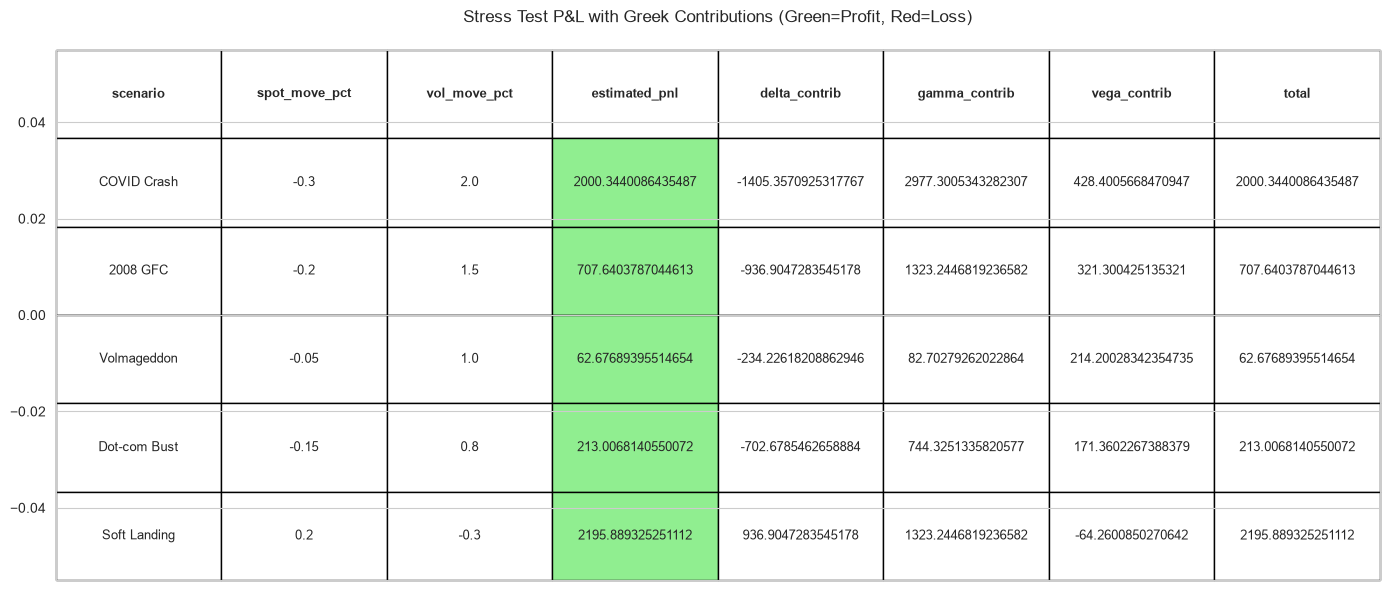

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('tight')
ax.xaxis.set_visible(False)

table = ax.table(
    cellText=stress_results_full.values,
    colLabels=stress_results_full.columns,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)

table.auto_set_font_size(False)
table.set_fontsize(9)

for i in range(len(stress_results_full.columns)):
    table[(0, i)].set_text_props(weight='bold')

for i in range(len(stress_results_full)):
    pnl = stress_results_full.iloc[i]['estimated_pnl']
    for j in range(len(stress_results_full.columns)):
        if stress_results_full.columns[j] == 'estimated_pnl':
            if pnl > 0:
                table[(i+1, j)].set_facecolor('lightgreen')
            elif pnl < 0:
                table[(i+1, j)].set_facecolor('lightcoral')

plt.title("Stress Test P&L with Greek Contributions (Green=Profit, Red=Loss)", fontsize=12, pad=20)
plt.tight_layout()
plt.show()

# Heatmap

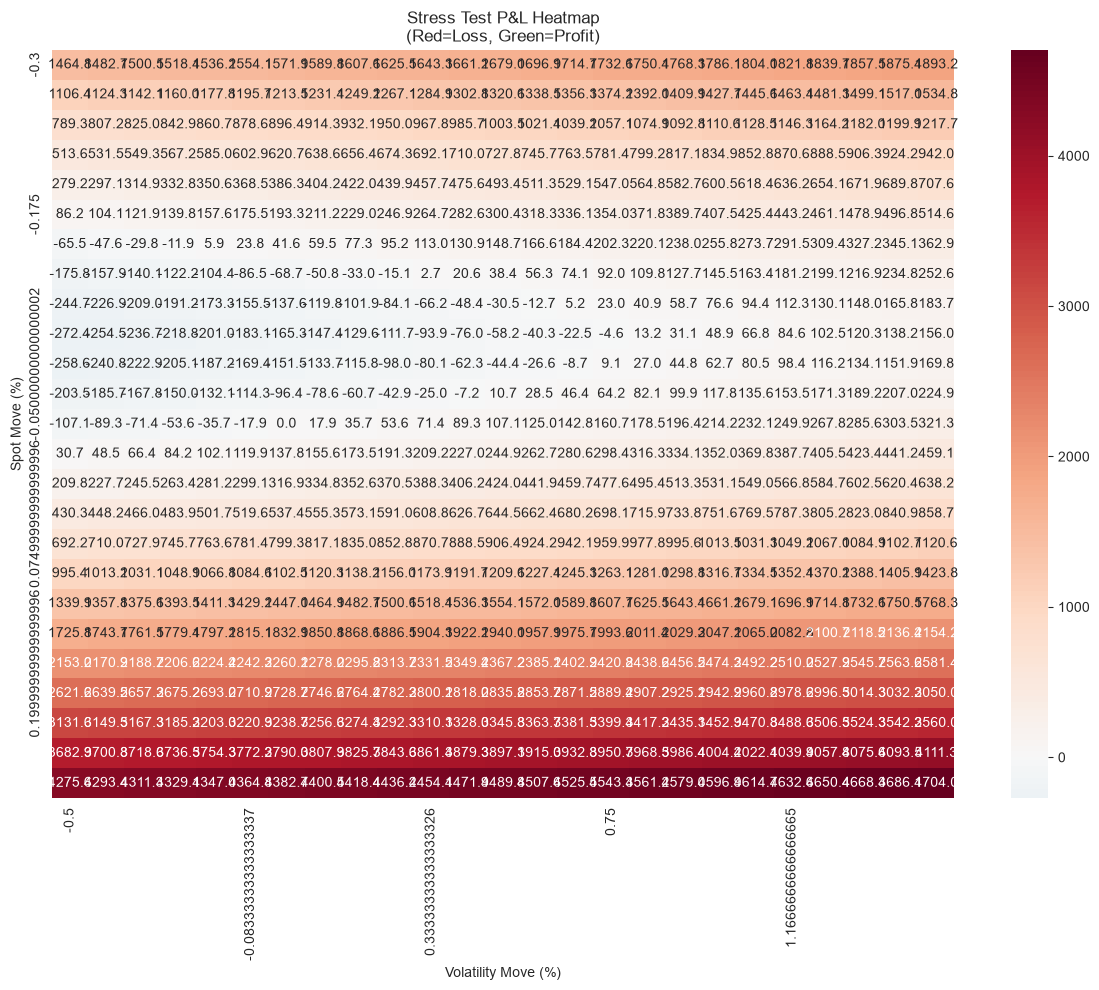

In [8]:
stress_surface = tester.stress_surface()

heatmap_data = stress_surface.pivot(index='spot_move_pct', columns='vol_move_pct', values='pnl')

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    heatmap_data,
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt='.1f',
    ax=ax,
    xticklabels=5,
    yticklabels=5
)

ax.set_xlabel('Volatility Move (%)')
ax.set_ylabel('Spot Move (%)')
ax.set_title('Stress Test P&L Heatmap\n(Red=Loss, Green=Profit)')
plt.tight_layout()
plt.show()

# P&L by Greek Contribution

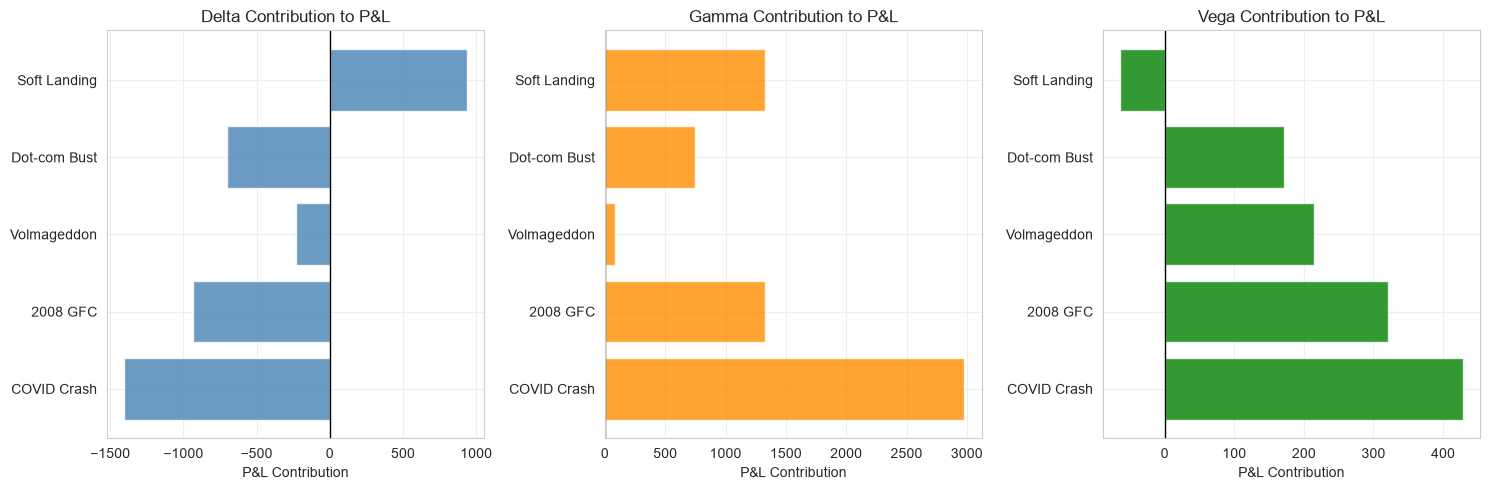

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

scenario_names = stress_results_full['scenario']
delta_vals = stress_results_full['delta_contrib']
gamma_vals = stress_results_full['gamma_contrib']
vega_vals = stress_results_full['vega_contrib']

axes[0].barh(scenario_names, delta_vals, color='steelblue', alpha=0.8)
axes[0].set_xlabel('P&L Contribution')
axes[0].set_title('Delta Contribution to P&L')
axes[0].axvline(0, color='black', lw=1)
axes[0].grid(True, alpha=0.3)

axes[1].barh(scenario_names, gamma_vals, color='darkorange', alpha=0.8)
axes[1].set_xlabel('P&L Contribution')
axes[1].set_title('Gamma Contribution to P&L')
axes[1].axvline(0, color='black', lw=1)
axes[1].grid(True, alpha=0.3)

axes[2].barh(scenario_names, vega_vals, color='green', alpha=0.8)
axes[2].set_xlabel('P&L Contribution')
axes[2].set_title('Vega Contribution to P&L')
axes[2].axvline(0, color='black', lw=1)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Taylor Expansion

In [10]:
print("\n" + "="*70)
print("TAYLOR EXPANSION FOR OPTIONS STRESS TESTING")
print("="*70)
print("\nApproximated price change using truncated Taylor Series:")
print("  dV ≈ Delta × dS + 0.5 × Gamma × dS² + Vega × dVol")
print("\nWhere:")
print("  Delta = dV/dS (sensitivity to spot price)")
print("  Gamma = d²V/dS² (convexity, acceleration of delta)")
print("  Vega = dV/dσ (sensitivity to volatility)")
print("\nThis is the delta-gamma-vega version of the Taylor Series for options.")
print("It applies to options (delta-gamma), bonds (duration-convexity), and portfolio VaR.")
print("="*70)


TAYLOR EXPANSION FOR OPTIONS STRESS TESTING

Approximated price change using truncated Taylor Series:
  dV ≈ Delta × dS + 0.5 × Gamma × dS² + Vega × dVol

Where:
  Delta = dV/dS (sensitivity to spot price)
  Gamma = d²V/dS² (convexity, acceleration of delta)
  Vega = dV/dσ (sensitivity to volatility)

This is the delta-gamma-vega version of the Taylor Series for options.
It applies to options (delta-gamma), bonds (duration-convexity), and portfolio VaR.


# Summary

In [11]:
print("\n" + "="*70)
print("KEY TAKEAWAYS — STRESS TESTING & SCENARIO ANALYSIS")
print("="*70)
print("\n1. Historical Scenarios:")
print("   - COVID Crash (Mar 2020): S -30%, Vol +200%")
print("   - 2008 GFC (Oct 2008): S -20%, Vol +150%")
print("   - Volmageddon (Feb 2018): S -5%, Vol +100%")
print("   - Dot-com Bust (2001): S -15%, Vol +80%")
print("   - Soft Landing (2023): S +20%, Vol -30%")
print("\n2. Taylor Expansion P&L:")
print("   - dV ≈ Delta×dS + 0.5×Gamma×dS² + Vega×dVol")
print("   - Shows which Greek drives most of the P&L")
print("   - Delta: directional risk, Gamma: convexity, Vega: vol risk")
print("\n3. Stress Surface Heatmap:")
print("   - P&L color-coded across grid of (spot move, vol move)")
print("   - Visualizes vulnerability across entire risk space")
print("\n4. Why this matters:")
print("   - This is word-for-word the BofA GRA job description")
print("   - 'Performs end-to-end market risk stress testing including scenario design,")
print("      scenario implementation, results consolidation, internal and external reporting'")
print("   - When interviewing for that role, describe this module specifically")
print("\n5. Industry relevance:")
print("   - Every trading desk does stress testing daily")
print("   - Identifies risk exposure not captured by other measures")
print("   - Limits stress exposure reflecting management tolerance")
print("="*70)


KEY TAKEAWAYS — STRESS TESTING & SCENARIO ANALYSIS

1. Historical Scenarios:
   - COVID Crash (Mar 2020): S -30%, Vol +200%
   - 2008 GFC (Oct 2008): S -20%, Vol +150%
   - Volmageddon (Feb 2018): S -5%, Vol +100%
   - Dot-com Bust (2001): S -15%, Vol +80%
   - Soft Landing (2023): S +20%, Vol -30%

2. Taylor Expansion P&L:
   - dV ≈ Delta×dS + 0.5×Gamma×dS² + Vega×dVol
   - Shows which Greek drives most of the P&L
   - Delta: directional risk, Gamma: convexity, Vega: vol risk

3. Stress Surface Heatmap:
   - P&L color-coded across grid of (spot move, vol move)
   - Visualizes vulnerability across entire risk space

4. Why this matters:
   - This is word-for-word the BofA GRA job description
   - 'Performs end-to-end market risk stress testing including scenario design,
      scenario implementation, results consolidation, internal and external reporting'
   - When interviewing for that role, describe this module specifically

5. Industry relevance:
   - Every trading desk does stress